|First Name     |Last Name    |MtkNr.      |Due Date  | 
|:-------------:|:-----------:|:----------:|:--------:|
| Mehran        | Farhadi     |K12506178    | 19.01.2025, 16:00

<h1 style="color:rgb(150,100,10)">Computer Vision Course</h1>
<h2 style="color:rgb(150,100,10)">Assignment 4 – 3D Reconstruction and Diffusion Models</h2>

<b>Authors:</b> O. Bimber, M. Abbass<br>
<b>Date:</b> 03-10-2025

<b>This file is part of the "Computer Vision Course 2025W" UE material.</b>

<h2 style="color:rgb(150,100,10)">Table of Contents</h2>
<ol>
    <a style="color:rgb(150,100,10)" href="#Depth-Map-from-Single-Image"><li style="font-size:large;font-weight:bold">Depth Map from Single Image [35 points]</li></a>
    <ol style="margin-bottom:15px">
        <a style="color:rgb(150,100,10)" href="#Visualize-the-Depth-Map"><li style="font-size:medium">Visualize the Depth Map</li></a>
        <a style="color:rgb(150,100,10)" href="#Use-your-own-Image"><li style="font-size:medium">Use your own Image</li></a>
</ol>
<a style="color:rgb(150,100,10)" href="#3d-Reconstruction-Using-VGGT"><li style="font-size:large;font-weight:bold">3D Reconstruction Using VGGT [35 points]</li></a>
    <ol style="margin-bottom:10px">
        <a style="color:rgb(150,100,10)" href="#Experiment-1"><li style="font-size:medium">Experiment 1</li></a>
        <a style="color:rgb(150,100,10)" href="#Experiment-2"><li style="font-size:medium">Experiment 2</li></a>
</ol>
    <a style="color:rgb(150,100,10)" href="#Diffusion-Model"><li style="font-size:large;font-weight:bold">Generating Images from Text using Diffusion Models [30 points]</li></a>
    <ol style="margin-bottom:10px">
        <a style="color:rgb(150,100,10)" href="#Stable-Diffusion-Based-Image-Generation"><li style="font-size:medium">Stable Diffusion-Based Image Generation</li></a>
</ol>
    
</ol>

<h2 style="color:rgb(255,0,0)">Please be aware that in this assignment we evaluate some models, which requires time. Thus, please avoid submitting your assignment at the last minute.</h2>

<h2 style="color:rgb(255,0,0)">Any content unrelated to the assignment, such as images, Python code (functions or classes), additional packages, or libraries, etc., will result in a deduction of 50 points.</h2>

<h1 style="color:rgb(255,0,0)">Important Note</h1>

<b>In this assignment, you may use the default parameters of any built-in function unless specified otherwise.</b>

<b style="color:rgb(255,70,0)">All cells must be executed; any unevaluated cell will not be considered, regardless of the correctness of the code.</b>

<b style="color:rgb(255,70,0)">All cells must be indexed; any non-indexed cell will not be considered.</b>

<b style="color:rgb(255,70,0)">Modifying the given code (even a single line), whether by replacing, changing, commenting, or removing, is strictly not allowed and will result in a loss of 50 points unless explicitly specified otherwise.</b>

<b style="color:rgb(255,70,0)">Redundant code, especially duplicating or copying the given code in different places, will result in a deduction of 25 points.</b>

<b style="color:rgb(255,70,0)">Importing the same packages multiple times in different cells will result in a deduction of 25 points.</b>

<b style="color:rgb(255,70,0)">All packages are imported in the first code cell. Any changes to this cell, including modifications, removals, or additions of packages or libraries, will result in a deduction of 50 points.</b>

<b>If you have GPU resources available on your machine, please utilize them; otherwise, you can use your CPU.</b>

<b>Always set the seed value to 123 unless specified otherwise.</b>

In [2]:
# Import all packages needed in this notebook. Any change or modification will lead to a loss of points
from matplotlib import pyplot as plt
import os
import cv2 as cv
import viser
import torch
from PIL import Image
from diffusers import StableDiffusionPipeline

if not os.path.exists('resources'): raise TypeError("Please create the resources folder and include all required files")
print('All necessary packages are successfully installed')

c:\Users\Lenovo\anaconda3\envs\com_vision\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Lenovo\anaconda3\envs\com_vision\Lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


All necessary packages are successfully installed


<a name="Depth-Map-from-Single-Image"></a><h2>Depth Map from Single Image</h2>
<a name="Visualize-the-Depth-Map"></a><h3>Visualize the Depth Map</h3>

<b>Exercise 1.1. [1 Points]</b>

<b>Goal:</b> Read the image and estimate the depth from it.

<b>Task</b>
<ul>
<li>Use the <i><b>imread</b></i> function from the <i><b>OpenCV</b></i> library to read the image <i><b>Img_A401</b></i> from the <i><b>resources</b></i> folder.</li>
<li>Convert the color space from <i><b>BGR</b></i> to <i><b>RGB</b></i>.</li>
</ul>
        
<b>Hint</b>
<ul> 
<li>Make sure that the image <i><b>Img_A401</b></i> is located in the <i><b>resources</b></i> folder.</li>
</ul>

(np.float64(-0.5), np.float64(2047.5), np.float64(1355.5), np.float64(-0.5))

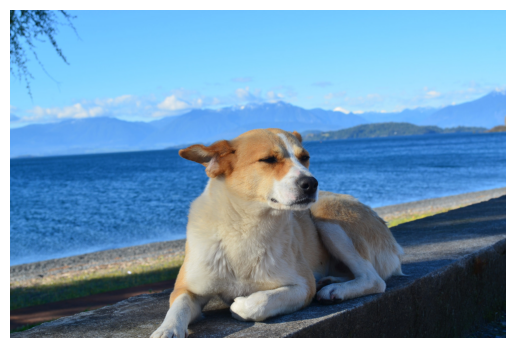

In [7]:
# code goes here
img = cv.imread(os.path.join("resources", "Img_A401.jpg"))
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img); plt.axis("off")

<b>Exercise 1.2. [3 Points]</b>

<b>Goal:</b> Load the MiDaS model.

<b>Task</b>
<ul>
<li>Use the <i><b>load_Model</b></i> function to load <i><b>MiDaS_small</b></i>.</li>
</ul>

<b>Hint</b>
<ul> 
<li>Make sure that the <i><b>load_Model</b></i> function has been executed.</li>
</ul>

<span style="color:rgb(200,10,10)">For your reference, the explanation of the model is available [here](https://arxiv.org/pdf/1907.01341) and [here](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=9711226).</span>

In [8]:
def load_Model(model_Ex12= "MiDaS_small" ):
    model_Ex12 = torch.hub.load("intel-isl/MiDaS", model_Ex12)
    model_Ex12.to('cpu')
    model_Ex12.eval()
    return model_Ex12

In [11]:
# code goes here
model = load_Model("MiDaS_small")


Using cache found in C:\Users\Lenovo/.cache\torch\hub\intel-isl_MiDaS_master
c:\Users\Lenovo\anaconda3\envs\com_vision\Lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to C:\Users\Lenovo/.cache\torch\hub\master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to C:\Users\Lenovo/.cache\torch\hub\checkpoints\tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to C:\Users\Lenovo/.cache\torch\hub\checkpoints\midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [02:40<00:00, 534kB/s]


<b>Exercise 1.3. [1 Point]</b>

<b>Goal:</b> Print the model.

<b>Task</b>
<ul>
<li>Print the architecture of the <i><b>MiDaS</b></i> model.</li>
</ul>

<b>Hint</b>
<ul> 
<li>Make sure that the <i><b>previous cells</b></i> have been successfully executed.</li>
</ul>

In [ ]:
# code goes here



<b>Exercise 1.4. [2 Points]</b>

<b>Goal:</b> Create the transformation for the MiDaS model.

<b>Task</b>
<ul> 
<li>Use the <i><b>creat_Transform</b></i> function to define the transformation pipeline for the model.</li>
<li>Use the <i><b>the small model</b></i>.</li>
</ul>

<b>Hint</b>
<ul>
<li>Make sure that the <i><b>load_Model</b></i> function has been executed.</li>
<li>The default value of the <i><b>model_Small</b></i> parameter is <i><b>True</b></i> when the model is small; otherwise, it should be <i><b>False</b></i>.</li>
</ul>

In [ ]:
def creat_Transform(model_Small = True):
    if model_Small==True:
        transform_Ex13 = transform_Ex13 = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform            
    else:
        transform_Ex13 = transform_Ex13 = torch.hub.load("intel-isl/MiDaS", "transforms").dpt_transform
    return transform_Ex13

In [ ]:
# code goes here



<b>Exercise 1.5. [4 Points]</b>

<b>Goal:</b> Transform the image for the MiDaS model.

<b>Task</b>
<ul>
<li>Apply the image from <i><b>Exercise 1.1</b></i> to the transformation created in <i><b>Exercise 1.4</b></i> for the MiDaS model.</li>
</ul>

<b>Hint</b>
<ul>
<li>Use the <i><b>cpu</b></i> to implement this transformation.</li>
</ul>

In [ ]:
# code goes here



<b>Exercise 1.6. [3 Points]</b>

<b>Goal:</b> Predict the depth map.

<b>Task</b>
<ul>
<li>Use the <i><b>prediction_Fn</b></i> function to predict the <i><b>depth</b></i>.</li>
<li>Provide the model you loaded from <i><b>Exercise 1.2</b></i>.</li>
<li>Provide the image from <i><b>Exercise 1.1</b></i> and the transformed image from <i><b>Exercise 1.5</b></i>.</li>
</ul>

<b>Hint</b>
<ul>
<li>Make sure that the <i><b>prediction_Fn</b></i> function has been executed.</li>
</ul>

In [ ]:
def prediction_Fn(model_Loaded, img_rgb_Ex16, input_Ex16, mode_Ex15= 'bicubic'):
    with torch.no_grad():
        prediction_Ex16 = model_Loaded(input_Ex16)
        prediction_Ex16 = torch.nn.functional.interpolate(prediction_Ex16.unsqueeze(1), 
                                                          size=img_rgb_Ex16.shape[:2], mode=mode_Ex15, align_corners=False).squeeze()
        output_Ex16 = prediction_Ex16.cpu().numpy()
    return output_Ex16

In [ ]:
# code goes here



<b>Exercise 1.7. [3 Points]</b>

<b>Goal:</b> Visualize the results.

<b>Task</b>
<ul>
<li>Use the <i><b>visulize_Rslt</b></i> function to display the results.</li>
<li>Provide the input image from <i><b>Exercise 1.1</b></i> and the resulting image from <i><b>Exercise 1.6</b></i>.</li>
</ul>
        
<b>Hint</b>
<ul> 
<li>Make sure to run the cell that defines the <i><b>visulize_Rslt</b></i> function before using it.</li>
</ul>

In [ ]:
def visulize_Rslt(input_Image, depth_Image):
    list_Images = [input_Image, depth_Image]
    titles = ['Original Image', 'Depth Map Image']
    plt.figure(figsize=(15,5))
    n = 2
    for i, p in enumerate(list_Images):
        plt.subplot(1,n, (i+1) )    
        plt.title( titles[i])
        plt.axis('off')
        plt.tight_layout()
        plt.imshow(p)
    plt.suptitle('Result', size=15)
    plt.tight_layout()
    plt.show()

In [ ]:
# code goes here



<a name="Use-your-own-Image"></a><h3>Use your own Image</h3>

<b>Exercise 1.8. [4 Points]</b>

<b>Goal:</b> Apply and test the model using your own <i><b>image and create a depth reconstruction failure.</b></i>.

<b>Task</b>
<ul>
<li>Select a scenery / object that causes the depth reconstruction to fail (think about what could cause a failure). </li> 
<li>Capture an image of this scenery / object and save the image in the <i><b>resources</b></i> folder.</li> 
<li>Repeat the same steps from <i><b>Exercise 1.1</b></i> to <i><b>Exercise 1.7</b></i> with the following changes.</li>
    <ul>
        <li>The loaded model should be <i><b>DPT_Hybrid</b></i> instead of <i><b>MiDaS_small</b></i>.</li>
        <li>Change the attribute <i><b>model_Small</b></i> to <i><b>False</b></i> when you call <i><b>creat_Transform</b></i>.</li>
    </ul>
</ul>

<b>Hint</b>
<ul> 
<li>Do not include any sensitive information in the video, such as <i><b>names, bank cards, license plates, etc</b></i>.</li>
<li><span style="color:rgb(180,10,10)">All necessary functions defined above must be called without copying them again. Otherwise, points will be deducted.</span></li>
</ul>

In [ ]:
# code goes here



<b>Exercise 1.8. [14 Points]</b>

<b>Question</b>
<ul> 

<li>Q1) Based on your failure results in Ex 1.7, explain the factors that make the depth estimation model fail or less robust. Also explain why it fails.</li>
<li>Q2) In Assignment 3, we used segmentation on RGB images. Can segmentation results be enhanced by considering depth in addition?</li>
</ul>

<b>Hint</b>
<ul>
<li>Each question must be answered in <i><b>1~4 lines</b></i> maximum. Exceeding 4 lines may result in point deductions.</li>
</ul>

<b>The answer goes here:</b>

A1) 

A2) 

<a name="3D-Reconstruction-Using-VGGT"></a><h2>3D Reconstruction Using VGGT</h2>

In this section, we use the VGGT algorithm. The link to VGGT can be found [Here](https://huggingface.co/spaces/facebook/vggt)

For your reference, the published paper is available [here](https://arxiv.org/pdf/2503.11651)

<a name="Experiment-1"></a><h3>Experiment 1</h3>

<b>Exercise 2.1. [6 Points]</b>

<b>Goal:</b> Reconstruct a 3D scene using videos.

<b>Task</b>
<ul>
<li>Use the <i><b>Vid_A401</b></i> file from the <i><b>resources</b></i> folder.</li>
<li>Drag and drop this video onto the VGGT website to reconstruct the 3D scene.</li>
<li>Take a snapshot after the reconstruction and save it in the <i><b>resources</b></i> folder in JPG format.</li>
<li>Visulize_3D_Result</b></i> function to display your 3D results.</li>
</ul>

<b>Hint</b>
<ul>
<li>The Link of VGGT is provided below.</li>
<li><span style="color:rgb(180,10,10)">The VGGT website provides limited resources per day. Therefore, you can perform your different reconstruction experiments on separate days.</span></li>
</ul>

Link to VGGT Website [Here](https://huggingface.co/spaces/facebook/vggt)

In [ ]:
def Visulize_3D_Result( image_Ex2_1: str):
    im_Ex2_1 = Image.open('resources/' + image_Ex2_1 + '.jpg')
    plt.imshow(im_Ex2_1), plt.axis('off'), plt.tight_layout(), plt.show()

In [ ]:
# code goes here



<b>Exercise 2.2. [8 Points]</b>

<b>Goal:</b> Use your own video.

<b>Task</b>
<ul>
<li>Record a video of your selected object and save it in the <i><b>resources</b></i> folder.</li>
<li>Drag and drop your video onto the VGGT website to reconstruct the 3D scene.</li>
<li>Take a snapshot after the reconstruction and save it in the <i><b>resources</b></i> folder in JPG format, under the name <i><b>'Result_A4-3'</b></i>.</li>
<li>Use the above <i><b>Visulize_3D_Result</b></i> function to display your 3D results saved as <i><b>'Result_A4-3'</b></i>.</li>
</ul>

<b>Hint</b>
<ul>
<li><span style="color:rgb(180,10,10)">The VGGT website provides limited resources per day. Therefore, you can perform your different reconstruction experiments on separate days.</span></li>
</ul>

In [ ]:
# code goes here



<a name="Experiment-2"></a><h3>Experiment 2</h3>

<b>Exercise 2.3. [6 Points]</b>

<b>Goal:</b>  Reconstruct a 3D scene using images.

<b>Task</b>
<ul>
<li>Use the images <i><b>Img_A402</b></i> and <i><b>Img_A403</b></i> from the <i><b>resources</b></i> folder.</li>
<li>Drag and drop these images onto the VGGT website to reconstruct the 3D scene.</li>
<li>Take a snapshot after the reconstruction and save it in the <i><b>resources</b></i> folder in JPG format.</li>
<li>Use the <i><b>Visulize_3D_Result</b></i> function to display your 3D results.</li>
</ul>

<b>Hint</b>
<ul>
<li>The VGGT website provides limited resources per day. Therefore, you can perform your different reconstruction experiments on separate days.</li>
</ul>

In [ ]:
# code goes here



<b>Exercise 2.4. [15 Points]</b>

<b>Question</b>
<ul> 

<li>Q1) What is the reason that the example in Ex. 2.3 failed? Explain in detail.</li>
<li>Q2) You learned about Neural Radiance Fields (NeRF) for 3D vision. What is the fundamental difference between NeRF and VGGT</li>
</ul>

<b>Hint</b>
<ul>
<li>Each question must be answered in <i><b>1~4 lines</b></i> maximum. Exceeding 4 lines may result in point deductions.</li>
</ul>

<b>The answer goes here:</b>

A1) 

A2) 

<a name="Head-topic-3"></a><h2>Generating Images from Text using Diffusion Models</h2>
<a name="Stable-Diffusion-Based-Image-Generation"></a><h3>Stable Diffusion-Based Image Generation</h3>

In this section, we utilize this [paper](https://arxiv.org/pdf/2112.10752)

<b>Exercise 3.1. [3 Points]</b>

<b>Goal:</b> Set up the Stable Diffusion Pipeline.

<b>Task</b>
<ul>
<li>Run the <i><b>set_StableDiffusion</b></i> function to set up the Stable Diffusion Pipeline.</li>
</ul>

<b>Hint</b>
<ul>
<li>Make sure to run the cell that defines the <i><b>set_StableDiffusion</b></i> function before using it.</li>
</ul>

In [ ]:
def set_StableDiffusion( ):
    pipeline_31 = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5")
    return pipeline_31

In [ ]:
# code goes here



<b>Exercise 3.2. [3 Points]</b>

<b>Goal:</b> Use the Stable Diffusion Pipeline.

<b>Task</b>
<ul>
<li>Move the pipeline from <i><b>Exercise 3.1</b></i> to either <i><b>CUDA</b></i> or <i><b>CPU</b></i>.</li>
</ul>

<b>Hint</b>
<ul>
<li>If you are using the CPU, the process may take some time.</li>
</ul>

In [ ]:
# code goes here



<b>Exercise 3.3. [3 Points]</b>

<b>Goal:</b> Provide the sentence as an input prompt for the model.

<b>Task</b>
<ul>
<li>Write the following sentence as a string <i><b>"baby with a dog"</b></i>.</li>
</ul>

<b>Hint</b>
<ul>
<li>Make sure that the sentence is in string format.</li>
</ul>

In [ ]:
# code goes here



<b>Exercise 3.4. [3 Points]</b>

<b>Goal:</b> Generate an image.

<b>Task</b>
<ul>
<li>Provide the <i><b>pipeline</b></i> from <i><b>Exercise 3.2</b></i> and the <i><b>prompt</b></i> from <i><b>Exercise 3.3</b></i> to the <i><b>generate_Image</b></i> function.</li>
</ul>

<b>Hint</b>
<ul>
<li>Make sure to run the cell that defines the <i><b>generate_Image</b></i> function before using it.</li>
</ul>

In [ ]:
def generate_Image(pipeline_34, prompt_34 ):
    image_34 = pipeline_34(prompt=prompt_34).images[0]
    return image_34

In [ ]:
# code goes here



<b>Exercise 3.5. [3 Points]</b>

<b>Goal:</b> Visualize the image.

<b>Task</b>
<ul>
<li>Use the <i><b>visualize_image</b></i> function to display the image.</li>
</ul>

<b>Hint</b>
<ul>
<li>Make sure to run the cell that defines the <i><b>visualize_image</b></i> function before using it.</li>
</ul>

In [ ]:
def visualize_image(image_35 ):
    plt.imshow(image_35), plt.axis('off'), plt.show()

In [ ]:
# code goes here



<b>Exercise 3.6. [3 Points]</b>

<b>Goal:</b> Use your own prompt.

<b>Task</b>
<ul>
<li>Write your own prompt as we did in Excersises 3.3.</li>
<li>Repeat Excersises 3.4 and 3.5 to show the generated image.</li>
</ul>

<b>Hint</b>
<ul>
<li><span style="color:rgb(180,10,10)">All necessary functions defined above must be called without copying them again. Otherwise, points will be deducted.</span></li>
</ul>

In [ ]:
# code goes here



<b>Exercise 3.7. [12 Points]</b>

<b>Question</b>
<ul> 

<li>Q1) The results of this diffusion approach suffer from hallucination often. You can easily create results that make no sense in detail. Can you exlain, in principle, what causes these hallucinations in image diffusion?
 
<li>Q2) Assume you are training a classifier to detect faces but lack sufficient training data. To what extent is it feasible to generate synthetic training data using a diffusion approach? Discuss your answer.

<li> Q3) Assume the goal is to train a classifier to detect lung cancer tumors in CT or MRI images, but sufficient training data is unavailable. Analyze whether a diffusion approach could successfully generate synthetic training data for this specific task. Discuss your answer.

</ul>

<b>Hint</b>
<ul>
<li>Each question must be answered in <i><b>1~4 lines</b></i> maximum. Exceeding 4 lines may result in point deductions.</li>
</ul>

<b>The answer goes here:</b>

A1) 

A2) 

A3) 